# Plot for the Binary system of 20 Solar mass and 15 Solar mass

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
### change file name
### change P,e,Z
### change x_max

In [3]:
path = "/home/poornima/Documents/BSE_METISSE_project/output_binary/"
file_name = "02000M_01500M.dat"
full_path = os.path.join(path, file_name)

data = np.loadtxt(full_path) 

# Remove the last row ( Because I think it is better)
data = data[:-1, :]

In [4]:
x_max = 30  ## Maximum X axis value (i.e. maximum time)

e = 0.4  ## eccentricity
p = 15   ## period
Z = 0.02 ## Metallicity

In [5]:
base_name = Path(file_name).stem

In [6]:
first_row = data[0]          
print(first_row)

[0.0000e+00 1.0000e+00 1.0000e+00 2.0000e+01 1.5000e+01 0.0000e+00
 0.0000e+00 7.6000e-01 6.9010e-01 1.7020e-01 1.6520e-01 4.6468e+00
 4.2989e+00 1.6580e+03 2.0320e+03 0.0000e+00 0.0000e+00 8.0640e-10
 1.0740e-09 5.4700e-03 6.6060e-03 8.3700e+01 4.0000e-01]


In [7]:
print(len(first_row))

23


In [8]:
first_row[10]

np.float64(0.1652)

In [9]:
## Select specific columns we need out of all the columns

col = {
    "time_Myr": data[:, 0],
    "k1": data[:, 1].astype(int),
    "k2": data[:, 2].astype(int),
    "m1_Msun": data[:, 3],
    "m2_Msun": data[:, 4],
    "sep_Rsun": data[:, 21],
    "R1/ROL1": data[:, 9],
    "R2/ROL2": data[:, 10],
    
}

In [10]:
kstar_translator = [
    {'long': 'Main Sequence (Low mass)', 'short': 'MS < 0.7', 'colour':(0.6, 1.0, 0.0, 1.0) }, ##(0.996078, 0.843476, 0.469158, 1.0)
    {'long': 'Main Sequence', 'short': 'MS', 'colour': (0.996078, 0.843476, 0.469158, 1.0)},
    {'long': 'Hertzsprung Gap', 'short': 'HG', 'colour':(0.939608, 0.471373, 0.094902, 1.0) },  ##
    {'long': 'First Giant Branch', 'short': 'FGB', 'colour': (0.0, 0.9, 0.9, 1.0)},  ##(0.716186, 0.833203, 0.916155, 1.0)
    {'long': 'Core Helium Burning', 'short': 'CHeB', 'colour': (0.29098, 0.59451, 0.78902, 1.0)},
    {'long': 'Early AGB', 'short': 'EAGB', 'colour': (0.294902, 0.690196, 0.384314, 1.0)},
    {'long': 'Thermally Pulsing AGB', 'short': 'TPAGB',
     'colour': (0.723122, 0.889612, 0.697178, 1.0)},
    {'long': 'Helium Main Sequence', 'short': 'HeMS', 'colour': (0.254627, 0.013882, 0.615419, 1.0)},
    {'long': 'Helium Hertsprung Gap', 'short': 'HeHG', 'colour': (0.562738, 0.051545, 0.641509, 1.0)},
    {'long': 'Helium Giant Branch', 'short': 'HeGB', 'colour': (0.798216, 0.280197, 0.469538, 1.0)},
    {'long': 'Helium White Dwarf', 'short': 'HeWD', 'colour': (0.368166, 0.232828, 0.148275, 1.0)},
    {'long': 'Carbon/Oxygen White Dwarf', 'short': 'COWD', 'colour': (0.620069, 0.392132, 0.249725, 1.0)},
    {'long': 'Oxygen/Neon White Dwarf', 'short': 'ONeWD', 'colour': (0.867128, 0.548372, 0.349225, 1.0)},
    {'long': 'Neutron Star', 'short': 'NS', 'colour': (0.501961, 0.501961, 0.501961, 1.0)},
    {'long': 'Black Hole', 'short': 'BH', 'colour': 'black'},
    {'long': 'Massless Remnant', 'short': 'MR', 'colour': (1.0, 1.0, 0.0, 1.0)}
    
]

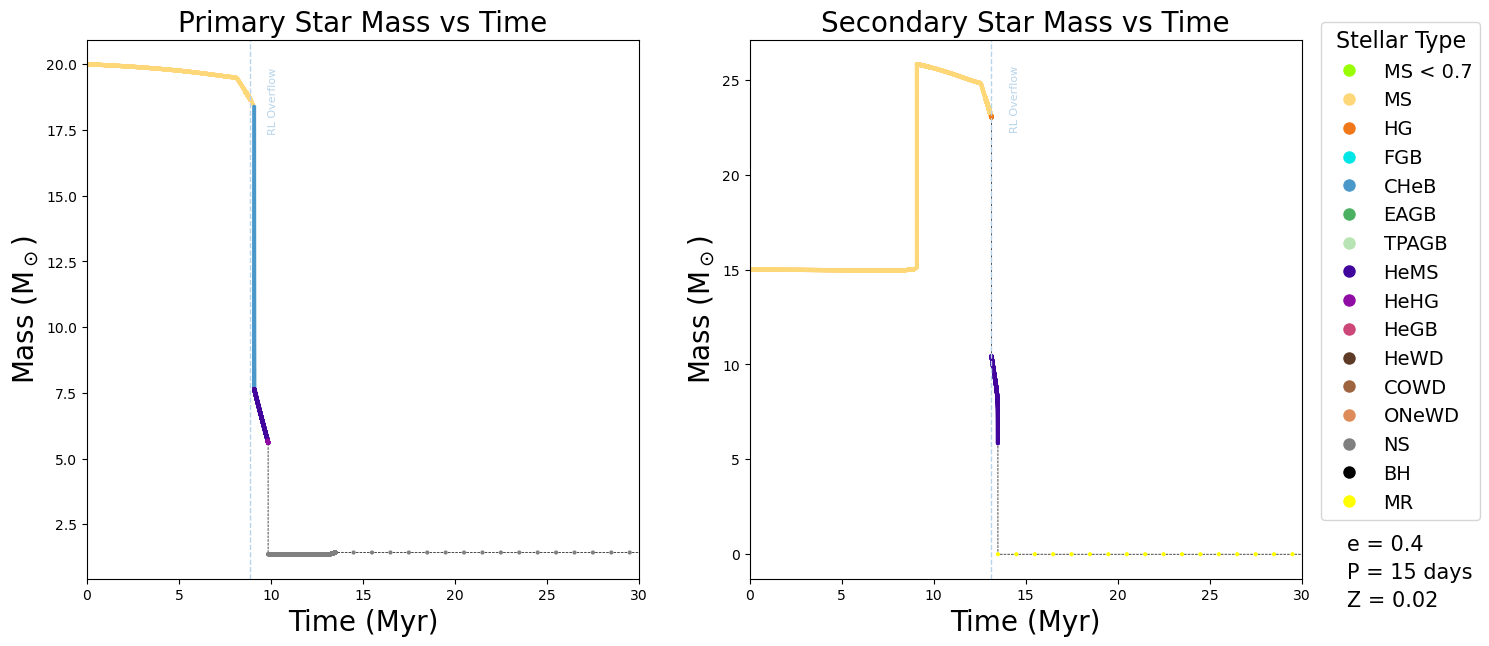

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    col["time_Myr"], 
    col["m1_Msun"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in col["k1"]], 
    s=4
)
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.plot(col["time_Myr"], col["m1_Msun"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel(r'Mass (M$_\odot$)',fontsize=20)
ax1.set_title('Primary Star Mass vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    col["time_Myr"], 
    col["m2_Msun"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in col["k2"]], 
    s=4
)
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.plot(col["time_Myr"], col["m2_Msun"], lw=0.5, color='black', linestyle='--',zorder=-1)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel(r'Mass (M$_\odot$)',fontsize=20)
ax2.set_title('Secondary Star Mass vs Time',fontsize=20)


# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(0, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=14,
    title_fontsize=16,
    loc='center right',
    bbox_to_anchor=(0.9, 0.55),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = col["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = col["time_Myr"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = col["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = col["time_Myr"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "Mass_vs_Time"


save_name = f"{base_name}_{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")

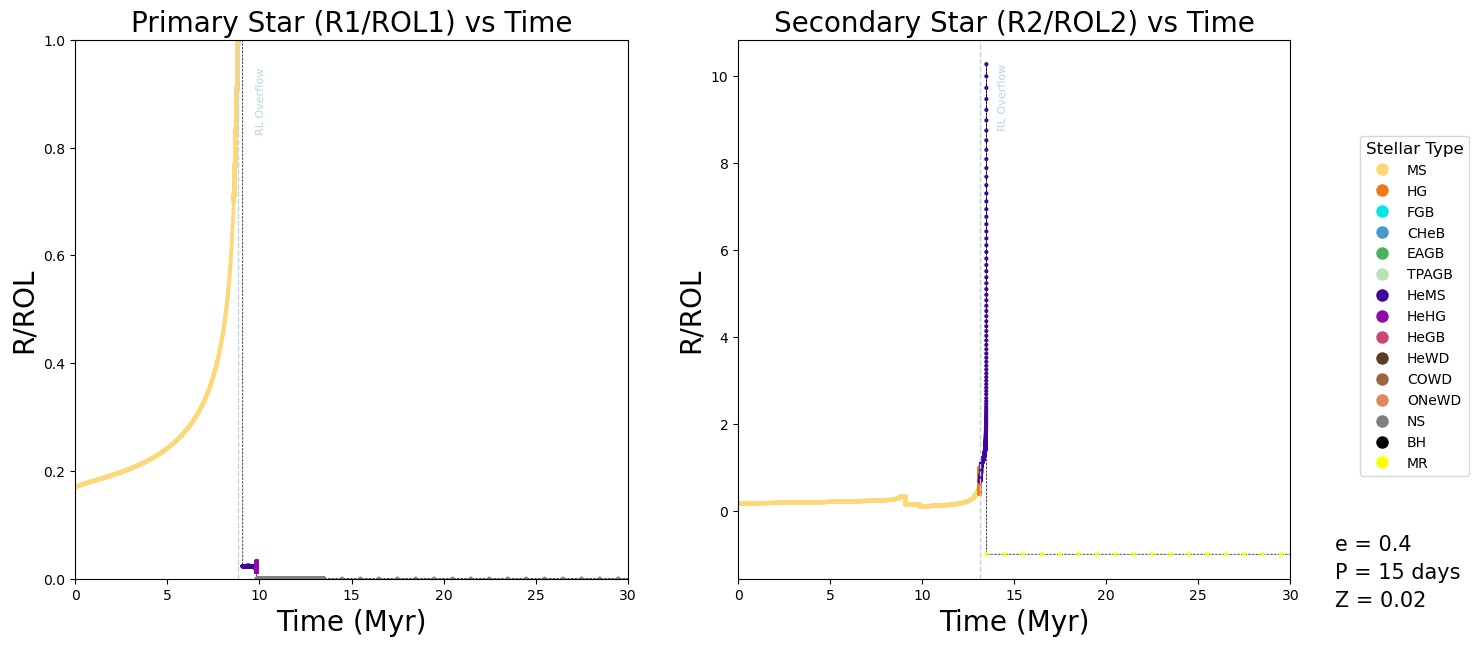

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    col["time_Myr"], 
    col["R1/ROL1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in col["k1"]], 
    s=4
)
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.set_ylim(ymin=0.0, ymax=1)
ax1.plot(col["time_Myr"], col["R1/ROL1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel('R/ROL',fontsize=20)
ax1.set_title('Primary Star (R1/ROL1) vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    col["time_Myr"], 
    col["R2/ROL2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in col["k2"]], 
    s=4
)
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.plot(col["time_Myr"], col["R2/ROL2"], lw=0.5, color='black',linestyle='--', zorder=-1)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel('R/ROL',fontsize=20)
ax2.set_title('Secondary Star (R2/ROL2) vs Time',fontsize=20)

# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(1, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=10,
    title_fontsize=12,
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = col["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = col["time_Myr"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = col["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = col["time_Myr"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "R_over_ROL_vs_Time"


save_name = f"{base_name}_{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")

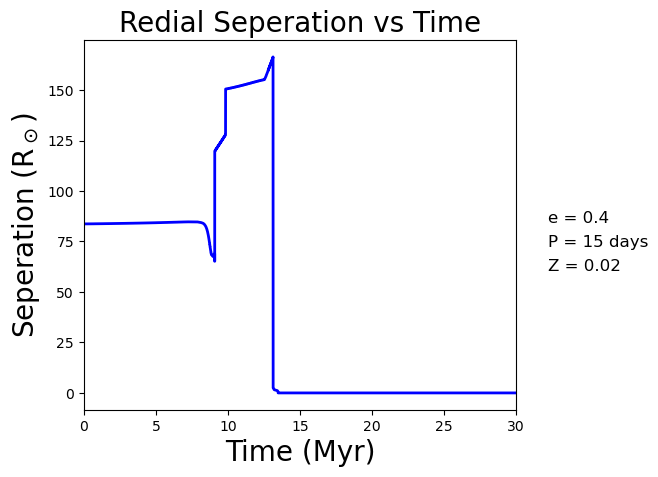

In [13]:
fig, ax = plt.subplots()

ax.set_xlim(xmin=0.0, xmax=x_max)
ax.plot(col["time_Myr"], col["sep_Rsun"], lw=2, color='blue' )

ax.set_xlabel(r'Time (Myr)',fontsize=20)
ax.set_ylabel(r'Seperation (R$_\odot$)',fontsize=20)
ax.set_title('Redial Seperation vs Time',fontsize=20)

y0 = 0.50
dy = 0.05

fig.text(0.85, y0, f'e = {e}', fontsize=12)
fig.text(0.85, y0 - dy, f'P = {p} days', fontsize=12)
fig.text(0.85, y0-2*dy, f'Z = {Z}', fontsize=12)



fig.subplots_adjust(right=0.8)   # leave space on the right

img_title = "Seperation_vs_Time"


save_name = f"{base_name}_{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")

In [14]:
# fig, ax = plt.subplots()
# ax.set_xlim(xmin=0.0, xmax=x_max)
# # plot the primary star
# ax.scatter(col["time_Myr"], col["m1_Msun"], c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
#    for k in col["k1"]], s=2)
# ax.plot(col["time_Myr"], col["m1_Msun"], lw=0.5, color='black', zorder=-1)

# # plot the secondary star
# ax.scatter(col["time_Myr"], col["m2_Msun"], c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
#    for k in col["k2"]], s=2)
# ax.plot(col["time_Myr"], col["m2_Msun"], lw=0.5, color='black', zorder=-1)


# ax.set_xlabel(r'Time (Myr)')
# ax.set_ylabel(r'Mass (M$_\odot$)')
# ax.set_title('Mass vs Time')

# for kstar in range(1,15):
#     ax.scatter([], [], c=[kstar_translator[kstar]["colour"]], label=kstar_translator[kstar]["short"], s=10)
#     ax.legend(title='Stellar Type', fontsize=6, title_fontsize=9, loc='lower right')

# ax.legend(
#     title='Stellar Type',
#     fontsize=8,
#     title_fontsize=10,
#     loc='center left',            # anchor point of legend
#     bbox_to_anchor=(1.02, 0.5),   # x=1.02 means just outside the right, y=0.5 = vertical center
#     borderaxespad=0               # optional: reduce padding
# )


# fig.subplots_adjust(right=0.8)   # leave space on the right

# img_title = "Mass_vs_Time_one_plot"


# save_name = f"{base_name}_{img_title}.png"

# fig.savefig(save_name, dpi=300, bbox_inches="tight")